When coherent light passes through a turbid medium like frosted glass or biological tissue, the transmitted wavefront is scrambled into a speckle pattern that looks like noise to the eye but still encodes information about the original object. The first part of this project asks: can a neural network read the class identity of an object directly from its speckle pattern, without reconstructing the image first?

Task: `speckle pattern → class label (0–9)` — no image recovery in the middle.

Rather than using a simulated scattering medium, every experiment in this notebook uses a real, experimentally measured transmission matrix (TM) from the Rice DSP public dataset (Metzler et al. 2017). Three different scattering media were measured:
- **AmpSLM_16x16** — thin diffuser, 16×16 input resolution, amplitude SLM
- **PhaseSLM_40x40** — thin diffuser, 40×40 input resolution, phase SLM
- **AmpSLM_64x64** — thin diffuser, 64×64 input resolution, amplitude SLM

Each TM was reconstructed from thousands of calibration measurements using the prVAMP algorithm. Using real TMs grounds the project in actual experimental physics rather than a statistical approximation.

We use the following project outline for reconstruction.
1. **Physical layer** — TM-based forward model $I_\text{out} = |T\,x|^2 + n$
2. **Data** — three real TMs + MNIST (resized to each TM's input resolution)
3. **Model** — small CNN classifier
4. **Robustness** — SNR sweep on the smallest TM (noiseless, 40, 20, 10 dB)
5. **Cross-TM comparison** — train on one medium, test on each of the three
6. **Analysis** — accuracy, per-class precision/recall, confusion matrices, failure cases

### Relation to the class
The TM is a physically measured, non-learnable physical layer upstream of the network the `y = f(W, x)` framing from lecture, except `W` is a measurement of a real scattering medium. This is an example of the "physical layer + deep network" concept covered in class.


---
## 1. Setup


In [1]:
# If any of these imports fail, run in a terminal:
#   pip install torch torchvision numpy matplotlib seaborn scikit-learn scipy h5py pandas

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report
import time, os, warnings
warnings.filterwarnings('ignore', category=UserWarning)

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device — uses GPU if available, otherwise CPU.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

os.makedirs('figures', exist_ok=True)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 160
plt.rcParams['savefig.bbox'] = 'tight'
sns.set_style('whitegrid')


Using device: cuda
PyTorch version: 2.10.0.dev20251118+cu128


The Rice DSP dataset provides three folders, each with a measured TM stored as a `.mat` file. We use `A_prVAMP.mat` (prVAMP is the higher-quality reconstruction algorithm from the paper) and filter out rows with poor residuals (< 0.4) following the MATLAB demo's criterion.

TransmissionMatrices/Coherent_Data/
    AmpSLM_16x16/A_prVAMP.mat     # n = 16*16 = 256 input pixels, m = 256*256 = 65536 detector pixels
    PhaseSLM_40x40/A_prVAMP.mat   # n = 40*40 = 1600 input pixels, m = 65536 detector pixels
    AmpSLM_64x64/A_prVAMP.mat     # n = 64*64 = 4096 input pixels, m = 65536 detector pixels
```
Each TM describes the complex input-output relationship of a coherent wavefront through a specific physical scattering medium. The three media differ in their SLM resolution (how finely we can modulate the input) but share the same detector.
```
The dataset is from http://dsp.rice.edu/research/transmissionmatrices/.


In [2]:
from pathlib import Path

TM_ROOT = Path('./TransmissionMatrices/Coherent_Data')

# Registry of the three TMs. input_side is sqrt(n).
TM_INFO = {
    'AmpSLM_16x16':   {'input_side': 16, 'path': TM_ROOT / 'AmpSLM_16x16'   / 'A_prVAMP.mat'},
    'PhaseSLM_40x40': {'input_side': 40, 'path': TM_ROOT / 'PhaseSLM_40x40' / 'A_prVAMP.mat'},
    'AmpSLM_64x64':   {'input_side': 64, 'path': TM_ROOT / 'AmpSLM_64x64'   / 'A_prVAMP.mat'},
}


def load_rice_tm(path: Path):
    """Load a Rice DSP TM. Handles both v7 (scipy.io) and v7.3 (HDF5/h5py) .mat formats.

    Returns:
        A: (M, N) complex64 transmission matrix
        residual: (M,) normalized residual vector (or None if not stored)
    """
    if not path.exists():
        raise FileNotFoundError(
            f'TM not found at {path}. Download from '
            f'http://dsp.rice.edu/research/transmissionmatrices/ and place under ./TransmissionMatrices/'
        )
    try:
        import scipy.io as sio
        mat = sio.loadmat(path)
        A = mat['A']
        resid = mat.get('residual_vector', None)
        if resid is not None:
            resid = resid.squeeze()
        return A.astype(np.complex64), resid
    except NotImplementedError:
        # v7.3 format — HDF5
        import h5py
        with h5py.File(path, 'r') as f:
            raw = f['A'][:]
            if raw.dtype.names and 'real' in raw.dtype.names:
                A = (raw['real'] + 1j * raw['imag']).astype(np.complex64)
            else:
                A = raw.astype(np.complex64)
            A = A.T  # MATLAB stores column-major; transpose to restore (M, N)
            resid = f['residual_vector'][:].squeeze() if 'residual_vector' in f else None
        return A, resid


def filter_good_rows(A, residual, threshold=0.4):
    """Keep only TM rows with residual < threshold (following the MATLAB demo)."""
    if residual is None:
        return A
    good = residual < threshold
    print(f'  Keeping {good.sum()} / {len(residual)} rows with residual < {threshold}')
    return A[good]


# Load all three TMs
TMs = {}
for name, info in TM_INFO.items():
    print(f'Loading {name}...')
    A, resid = load_rice_tm(info['path'])
    A = filter_good_rows(A, resid, threshold=0.4)
    TMs[name] = {
        'A': A,
        'input_side': info['input_side'],
        'M_full': A.shape[0],
    }
    print(f'  Shape: {A.shape}  |A| stats: mean={np.abs(A).mean():.4f}, std={np.abs(A).std():.4f}')


Loading AmpSLM_16x16...
  Keeping 65536 / 65536 rows with residual < 0.4
  Shape: (65536, 256)  |A| stats: mean=0.3227, std=0.1957
Loading PhaseSLM_40x40...
  Keeping 65535 / 65536 rows with residual < 0.4
  Shape: (65535, 1600)  |A| stats: mean=0.0792, std=0.0587
Loading AmpSLM_64x64...
  Keeping 65536 / 65536 rows with residual < 0.4
  Shape: (65536, 4096)  |A| stats: mean=0.0427, std=0.0290


---
## 3. Forward Model and Data Pipeline

### The scattering model
Given a flattened MNIST digit $x$ (treated as an amplitude wavefront) and a real measured TM $T$, the intensity at the detector is:

$$I_\text{out} = |T\,x|^2 + n$$

where $n$ is additive Gaussian camera noise at a chosen SNR. The $|\cdot|^2$ is elementwise — the camera measures intensity, not complex field.

### Two practical steps before feeding to the CNN

**Resize MNIST to match each TM's input resolution.** MNIST is 28×28. AmpSLM_16x16 needs 16×16 input, PhaseSLM_40x40 needs 40×40, AmpSLM_64x64 needs 64×64. `torchvision.transforms.Resize` handles this.

**Subsample detector pixels to a fixed output size.** Each TM has ~65,000 "good" rows after filtering. A 65,000-wide speckle vector is overkill for classification (and memory-heavy). We consistently keep 1024 rows (reshape to 32×32 speckle) so every TM produces CNN-friendly 32×32 inputs. Using a fixed random seed for the row selection makes this reproducible.


In [3]:
OUTPUT_SIDE = 32          # speckle images will always be 32x32 (1024 detector pixels)
M_KEEP = OUTPUT_SIDE ** 2

# Subsample each TM's detector rows to M_KEEP consistent rows
rng_sample = np.random.default_rng(SEED)
for name, entry in TMs.items():
    M_full = entry['M_full']
    if M_full < M_KEEP:
        raise RuntimeError(f'{name} has only {M_full} good rows, need {M_KEEP}')
    keep_idx = rng_sample.choice(M_full, size=M_KEEP, replace=False)
    entry['A_sub'] = entry['A'][keep_idx].astype(np.complex64)    # (1024, N)
    print(f'{name}: A_sub shape = {entry["A_sub"].shape}')


def propagate_through_tm(x: np.ndarray, T: np.ndarray, snr_db=None, rng=None) -> np.ndarray:
    """Push a batch of flattened inputs through a TM. Returns (B, M) intensity."""
    if rng is None:
        rng = np.random.default_rng()
    E_out = T @ x.T.astype(np.complex64)       # (M, B)
    I_out = (np.abs(E_out) ** 2).T             # (B, M)
    if snr_db is not None:
        signal_power = I_out.mean()
        noise_power = signal_power / (10.0 ** (snr_db / 10.0))
        noise = rng.standard_normal(I_out.shape).astype(np.float32) * np.sqrt(noise_power)
        I_out = np.clip(I_out + noise, 0, None)
    return I_out.astype(np.float32)


class SpeckleDataset(Dataset):
    """Resizes MNIST to match a TM's input side, pushes through the TM, returns speckle + label."""

    def __init__(self, mnist_ds, T, input_side, output_side, snr_db=None, subset_size=None):
        self.mnist_ds = mnist_ds
        self.T = T
        self.input_side = input_side
        self.output_side = output_side
        self.snr_db = snr_db
        self.rng = np.random.default_rng()
        # Resize transform applied per-sample (Resize on PIL then ToTensor)
        self.resize = transforms.Compose([
            transforms.Resize((input_side, input_side)),
            transforms.ToTensor(),
        ])
        if subset_size is not None and subset_size < len(mnist_ds):
            idx = np.random.default_rng(SEED).choice(len(mnist_ds), subset_size, replace=False)
            self.indices = idx.tolist()
        else:
            self.indices = list(range(len(mnist_ds)))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        # mnist_ds was loaded with transform=None, so indexing returns (PIL.Image, int).
        # We apply our own resize+ToTensor inside this method for per-sample control.
        idx = self.indices[i]
        pil_img, label = self.mnist_ds[idx]
        img = self.resize(pil_img)                         # (1, input_side, input_side) in [0,1]
        x = img.numpy().reshape(1, -1)                     # (1, N)
        I = propagate_through_tm(x, self.T, snr_db=self.snr_db, rng=self.rng)  # (1, M)
        I = I.reshape(self.output_side, self.output_side)
        I = (I - I.mean()) / (I.std() + 1e-8)              # per-sample standardize
        return torch.from_numpy(I).unsqueeze(0).float(), int(label)


# Load MNIST WITHOUT a pre-applied transform — we resize inside SpeckleDataset to match each TM
mnist_train_raw = datasets.MNIST('./data', train=True,  download=True, transform=None)
mnist_test_raw  = datasets.MNIST('./data', train=False, download=True, transform=None)
print(f'MNIST train: {len(mnist_train_raw)}, test: {len(mnist_test_raw)}')


AmpSLM_16x16: A_sub shape = (1024, 256)
PhaseSLM_40x40: A_sub shape = (1024, 1600)
AmpSLM_64x64: A_sub shape = (1024, 4096)
MNIST train: 60000, test: 10000


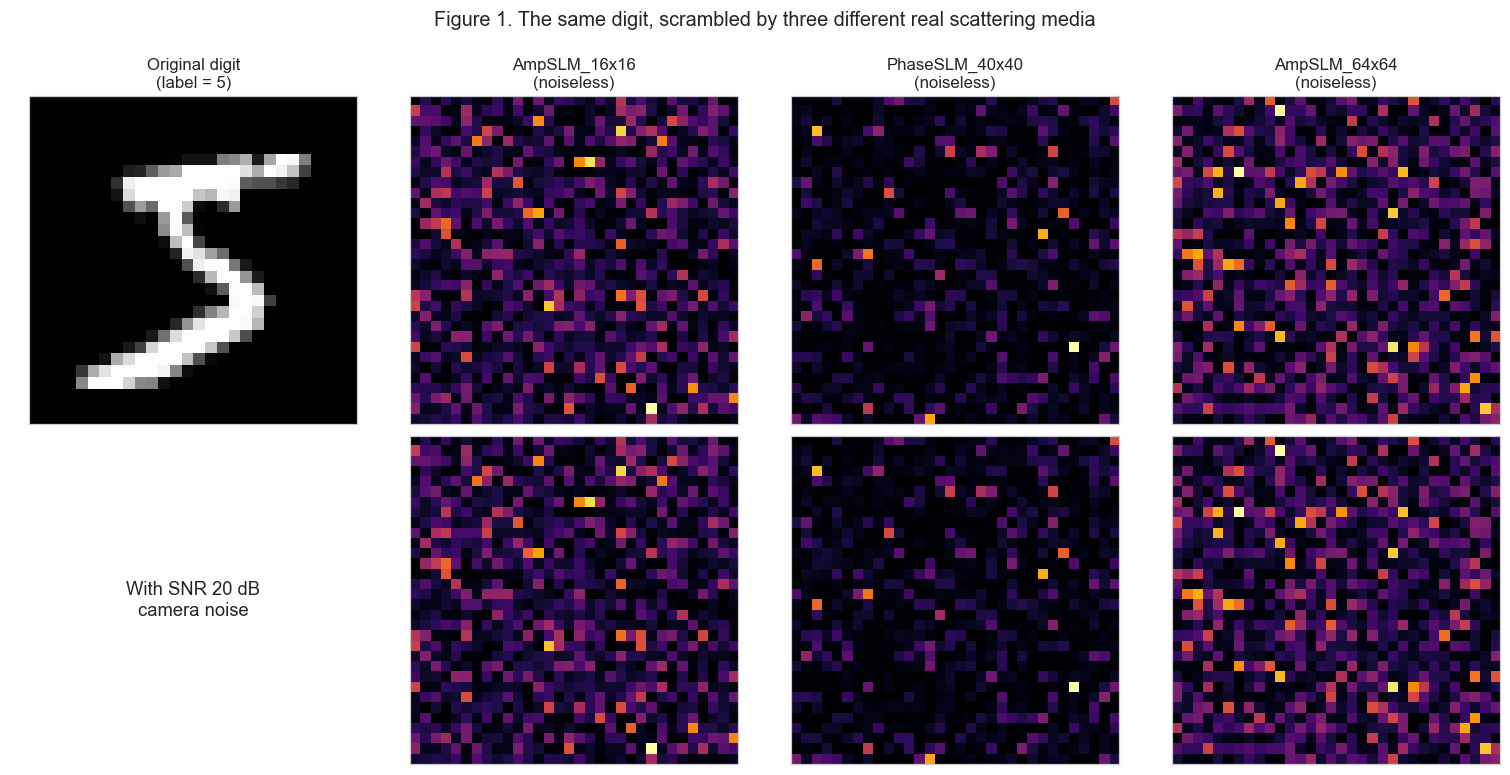

In [4]:
# Figure 1 — the same digit pushed through each of the three real TMs
sample_pil, sample_lbl = mnist_train_raw[0]
resize28 = transforms.Compose([transforms.ToTensor()])
orig_arr = resize28(sample_pil).numpy().squeeze()    # (28, 28)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# Top row: original + 3 noiseless speckles
axes[0, 0].imshow(orig_arr, cmap='gray')
axes[0, 0].set_title(f'Original digit\n(label = {sample_lbl})', fontsize=11)

# Bottom row: 3 speckles with SNR 20 dB noise
axes[1, 0].axis('off')
axes[1, 0].text(0.5, 0.5, 'With SNR 20 dB\ncamera noise',
                ha='center', va='center', fontsize=12, transform=axes[1, 0].transAxes)

rng_fig = np.random.default_rng(SEED)
for col, (name, entry) in enumerate(TMs.items(), start=1):
    resize = transforms.Compose([
        transforms.Resize((entry['input_side'], entry['input_side'])),
        transforms.ToTensor(),
    ])
    x = resize(sample_pil).numpy().reshape(1, -1)

    speckle_clean = propagate_through_tm(x, entry['A_sub'], snr_db=None).reshape(OUTPUT_SIDE, OUTPUT_SIDE)
    speckle_noisy = propagate_through_tm(x, entry['A_sub'], snr_db=20, rng=rng_fig).reshape(OUTPUT_SIDE, OUTPUT_SIDE)

    axes[0, col].imshow(speckle_clean, cmap='inferno')
    axes[0, col].set_title(f'{name}\n(noiseless)', fontsize=11)
    axes[1, col].imshow(speckle_noisy, cmap='inferno')

for ax in axes.flat:
    if ax.has_data():
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Figure 1. The same digit, scrambled by three different real scattering media',
             y=1.00, fontsize=13)
plt.tight_layout()
plt.savefig('figures/fig1_three_tms.png')
plt.show()


---
## 4. Model — CNN Classifier

A standard CNN: two conv+pool blocks → FC head → softmax over 10 classes. The input is always a 32×32 speckle pattern (regardless of which TM produced it), so the same architecture works for all three media.


In [5]:
class SpeckleCNN(nn.Module):
    def __init__(self, input_side=32, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        final_side = input_side // 4  # after two 2x pools
        self.fc1 = nn.Linear(64 * final_side * final_side, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


print(f'SpeckleCNN parameters: {count_params(SpeckleCNN()):,}')


SpeckleCNN parameters: 544,522


---
## 5. Training Loop


In [6]:
def train_model(model, train_loader, val_loader, epochs=5, lr=1e-3, verbose=True):
    """Standard supervised training with Adam + cross-entropy. Returns history dict."""
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        t0 = time.time()
        model.train()
        tl, tc, tt = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            tl += loss.item() * xb.size(0)
            tc += (logits.argmax(1) == yb).sum().item()
            tt += xb.size(0)

        model.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                vl += loss.item() * xb.size(0)
                vc += (logits.argmax(1) == yb).sum().item()
                vt += xb.size(0)

        history['train_loss'].append(tl / tt); history['train_acc'].append(tc / tt)
        history['val_loss'].append(vl / vt);   history['val_acc'].append(vc / vt)
        if verbose:
            print(f'  Epoch {epoch+1}/{epochs} | '
                  f'train loss {tl/tt:.4f} acc {tc/tt:.3f} | '
                  f'val loss {vl/vt:.4f} acc {vc/vt:.3f} | '
                  f'{time.time()-t0:.1f}s')
    return history


def evaluate_model(model, loader):
    model = model.to(DEVICE).eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            all_preds.append(logits.argmax(1).cpu().numpy())
            all_true.append(yb.numpy())
    preds = np.concatenate(all_preds); true = np.concatenate(all_true)
    acc = (preds == true).mean()
    return preds, true, acc


---
## 6. Experiment 1 — Noise Robustness (AmpSLM_16x16)

We pick the smallest real TM (AmpSLM_16x16) as the default testbed: it's the fastest to train on, and the downstream results will carry over conceptually to the larger TMs. Sweep SNR over {noiseless, 40, 20, 10} dB.


In [7]:
TRAIN_SUBSET = 10_000
TEST_SUBSET  = 2_000
BATCH_SIZE   = 128
EPOCHS       = 5

SNR_LEVELS = [None, 40, 20, 10]
SNR_NAMES  = ['noiseless', '40 dB', '20 dB', '10 dB']

PRIMARY_TM = 'AmpSLM_16x16'
primary_entry = TMs[PRIMARY_TM]

snr_results = {}

for snr, name in zip(SNR_LEVELS, SNR_NAMES):
    print(f'\n=== {PRIMARY_TM}, SNR: {name} ===')
    train_ds = SpeckleDataset(mnist_train_raw, primary_entry['A_sub'],
                              primary_entry['input_side'], OUTPUT_SIDE,
                              snr_db=snr, subset_size=TRAIN_SUBSET)
    test_ds  = SpeckleDataset(mnist_test_raw,  primary_entry['A_sub'],
                              primary_entry['input_side'], OUTPUT_SIDE,
                              snr_db=snr, subset_size=TEST_SUBSET)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

    torch.manual_seed(SEED)
    model = SpeckleCNN(input_side=OUTPUT_SIDE)
    _ = train_model(model, train_loader, test_loader, epochs=EPOCHS, verbose=False)
    preds, true, acc = evaluate_model(model, test_loader)
    print(f'  Test accuracy: {acc:.3f}')
    snr_results[name] = {'acc': acc, 'preds': preds, 'true': true, 'model': model}



=== AmpSLM_16x16, SNR: noiseless ===
  Test accuracy: 0.944

=== AmpSLM_16x16, SNR: 40 dB ===
  Test accuracy: 0.950

=== AmpSLM_16x16, SNR: 20 dB ===
  Test accuracy: 0.951

=== AmpSLM_16x16, SNR: 10 dB ===
  Test accuracy: 0.951


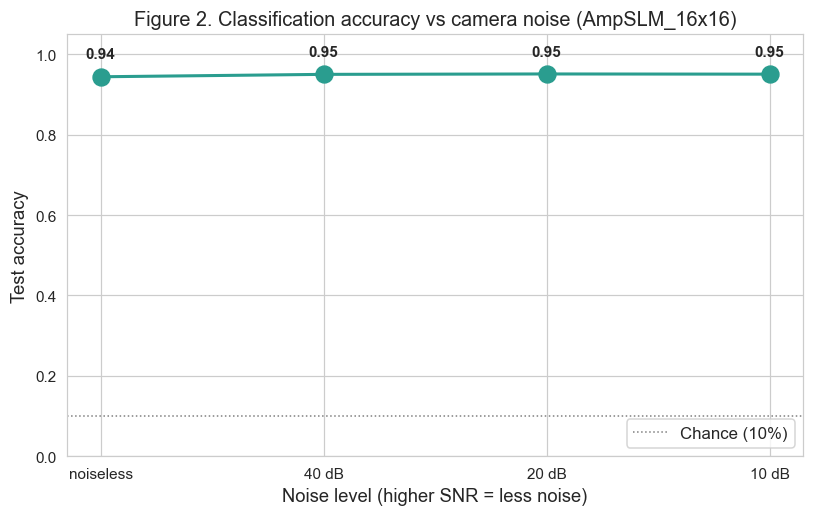

In [8]:
# Figure 2 — accuracy vs SNR on the primary TM
fig, ax = plt.subplots(figsize=(7.5, 4.8))
xs = np.arange(len(SNR_NAMES))
accs = [snr_results[n]['acc'] for n in SNR_NAMES]

ax.plot(xs, accs, 'o-', linewidth=2, markersize=11, color='#2a9d8f')
ax.set_xticks(xs); ax.set_xticklabels(SNR_NAMES)
ax.set_xlabel('Noise level (higher SNR = less noise)', fontsize=12)
ax.set_ylabel('Test accuracy', fontsize=12)
ax.set_ylim(0, 1.05)
ax.axhline(0.1, color='gray', linestyle=':', linewidth=1, label='Chance (10%)')
ax.set_title(f'Figure 2. Classification accuracy vs camera noise ({PRIMARY_TM})', fontsize=13)
ax.legend(fontsize=11, loc='lower right')
for x, a in zip(xs, accs):
    ax.annotate(f'{a:.2f}', (x, a), textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig2_snr_sweep.png')
plt.show()


---
## 7. Confusion Matrix and Failure Cases (SNR 20 dB)

SNR 20 dB is our default "realistic but challenging" operating point — noticeable noise, but the network still works. Let's see which digits get confused.


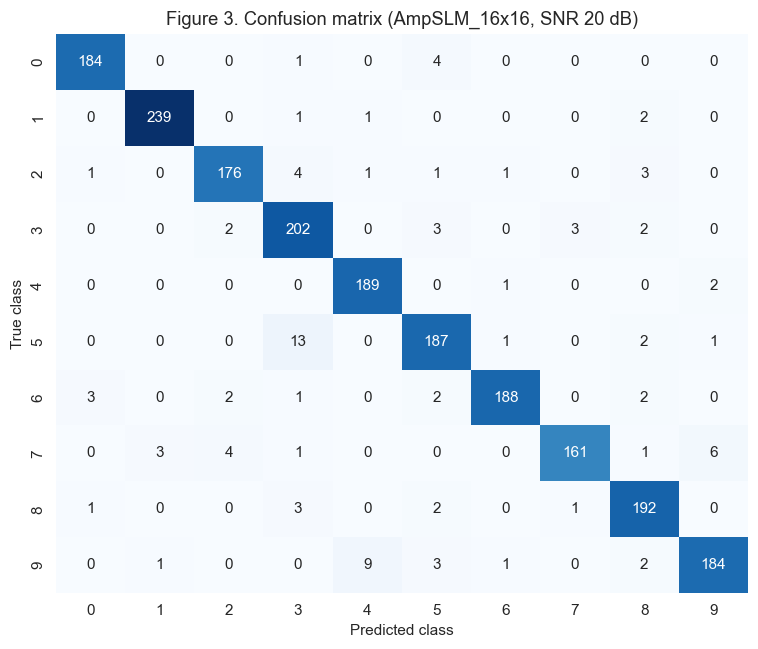


Per-class precision/recall (AmpSLM_16x16 @ SNR 20 dB):
              precision    recall  f1-score   support

           0      0.974     0.974     0.974       189
           1      0.984     0.984     0.984       243
           2      0.957     0.941     0.949       187
           3      0.894     0.953     0.922       212
           4      0.945     0.984     0.964       192
           5      0.926     0.917     0.921       204
           6      0.979     0.949     0.964       198
           7      0.976     0.915     0.944       176
           8      0.932     0.965     0.948       199
           9      0.953     0.920     0.936       200

    accuracy                          0.951      2000
   macro avg      0.952     0.950     0.951      2000
weighted avg      0.952     0.951     0.951      2000



In [9]:
preds = snr_results['20 dB']['preds']
true  = snr_results['20 dB']['true']
cm = confusion_matrix(true, preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=range(10), yticklabels=range(10))
ax.set_xlabel('Predicted class'); ax.set_ylabel('True class')
ax.set_title(f'Figure 3. Confusion matrix ({PRIMARY_TM}, SNR 20 dB)')
plt.tight_layout()
plt.savefig('figures/fig3_confusion_matrix.png')
plt.show()

print(f'\nPer-class precision/recall ({PRIMARY_TM} @ SNR 20 dB):')
print(classification_report(true, preds, digits=3))


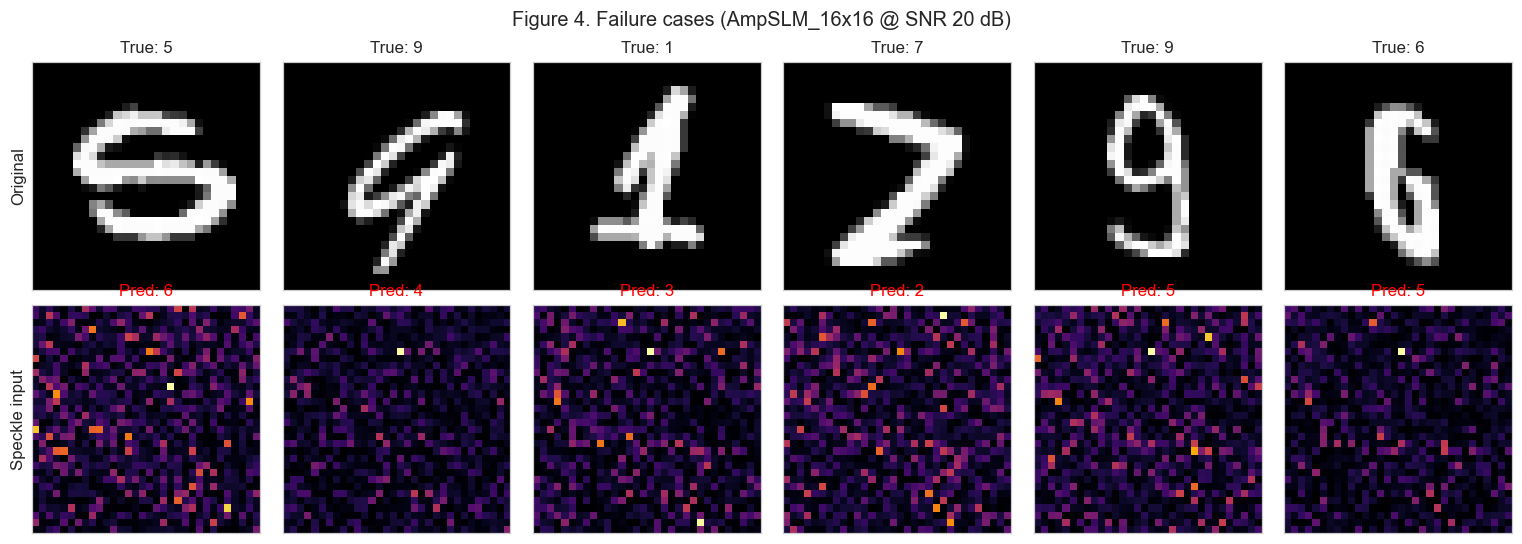

In [10]:
# Figure 4 — failure case grid
test_ds_vis = SpeckleDataset(mnist_test_raw, primary_entry['A_sub'],
                              primary_entry['input_side'], OUTPUT_SIDE,
                              snr_db=20, subset_size=TEST_SUBSET)
wrong_idx = np.where(preds != true)[0][:6]

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i, idx in enumerate(wrong_idx):
    speckle, lbl = test_ds_vis[idx]
    speckle_img = speckle.squeeze().numpy()
    orig_pil, _ = mnist_test_raw[test_ds_vis.indices[idx]]
    orig_img = np.array(orig_pil) / 255.0

    axes[0, i].imshow(orig_img, cmap='gray')
    axes[0, i].set_title(f'True: {lbl}', fontsize=11)
    axes[1, i].imshow(speckle_img, cmap='inferno')
    axes[1, i].set_title(f'Pred: {preds[idx]}', fontsize=11, color='red')
    for r in range(2):
        axes[r, i].set_xticks([]); axes[r, i].set_yticks([])
axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('Speckle input', fontsize=11)
plt.suptitle(f'Figure 4. Failure cases ({PRIMARY_TM} @ SNR 20 dB)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/fig4_failure_cases.png')
plt.show()


---
## 8. Experiment 2 — Cross-TM Comparison

Train a CNN on each of the three real scattering media, then evaluate each classifier on speckle patterns from each of the three media. This produces a 3×3 grid of accuracies that answers two questions at once:

1. **Diagonal entries** — how hard is classification on each medium individually? (Different input resolutions mean different amounts of information per digit.)
2. **Off-diagonal entries** — does a classifier trained on medium A work on medium B? Our prediction from the design: each TM is a completely different random projection, so cross-TM accuracy should collapse to near-chance.

All experiments use SNR 20 dB.


In [11]:
# Train one CNN per TM, then evaluate every (train_tm, test_tm) combination at SNR 20 dB
TM_NAMES = list(TMs.keys())  # ['AmpSLM_16x16', 'PhaseSLM_40x40', 'AmpSLM_64x64']
N_TMS = len(TM_NAMES)

trained_on_tm = {}     # maps train_tm_name -> trained model

print('Training one CNN per TM...')
for train_name in TM_NAMES:
    print(f'\n=== Training on {train_name} ===')
    entry = TMs[train_name]
    train_ds = SpeckleDataset(mnist_train_raw, entry['A_sub'], entry['input_side'],
                              OUTPUT_SIDE, snr_db=20, subset_size=TRAIN_SUBSET)
    val_ds   = SpeckleDataset(mnist_test_raw,  entry['A_sub'], entry['input_side'],
                              OUTPUT_SIDE, snr_db=20, subset_size=TEST_SUBSET)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

    torch.manual_seed(SEED)
    model = SpeckleCNN(input_side=OUTPUT_SIDE)
    _ = train_model(model, train_loader, val_loader, epochs=EPOCHS, verbose=False)
    trained_on_tm[train_name] = model

# Evaluate every train-on / test-on pair
cross_tm_acc = np.zeros((N_TMS, N_TMS), dtype=np.float32)
print('\nCross-TM evaluation...')
for i, train_name in enumerate(TM_NAMES):
    for j, test_name in enumerate(TM_NAMES):
        entry = TMs[test_name]
        test_ds = SpeckleDataset(mnist_test_raw, entry['A_sub'], entry['input_side'],
                                 OUTPUT_SIDE, snr_db=20, subset_size=TEST_SUBSET)
        test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
        _, _, acc = evaluate_model(trained_on_tm[train_name], test_loader)
        cross_tm_acc[i, j] = acc
        print(f'  Train on {train_name:18s}, test on {test_name:18s}: {acc:.3f}')


Training one CNN per TM...

=== Training on AmpSLM_16x16 ===

=== Training on PhaseSLM_40x40 ===

=== Training on AmpSLM_64x64 ===

Cross-TM evaluation...
  Train on AmpSLM_16x16      , test on AmpSLM_16x16      : 0.952
  Train on AmpSLM_16x16      , test on PhaseSLM_40x40    : 0.082
  Train on AmpSLM_16x16      , test on AmpSLM_64x64      : 0.101
  Train on PhaseSLM_40x40    , test on AmpSLM_16x16      : 0.136
  Train on PhaseSLM_40x40    , test on PhaseSLM_40x40    : 0.932
  Train on PhaseSLM_40x40    , test on AmpSLM_64x64      : 0.123
  Train on AmpSLM_64x64      , test on AmpSLM_16x16      : 0.105
  Train on AmpSLM_64x64      , test on PhaseSLM_40x40    : 0.113
  Train on AmpSLM_64x64      , test on AmpSLM_64x64      : 0.941


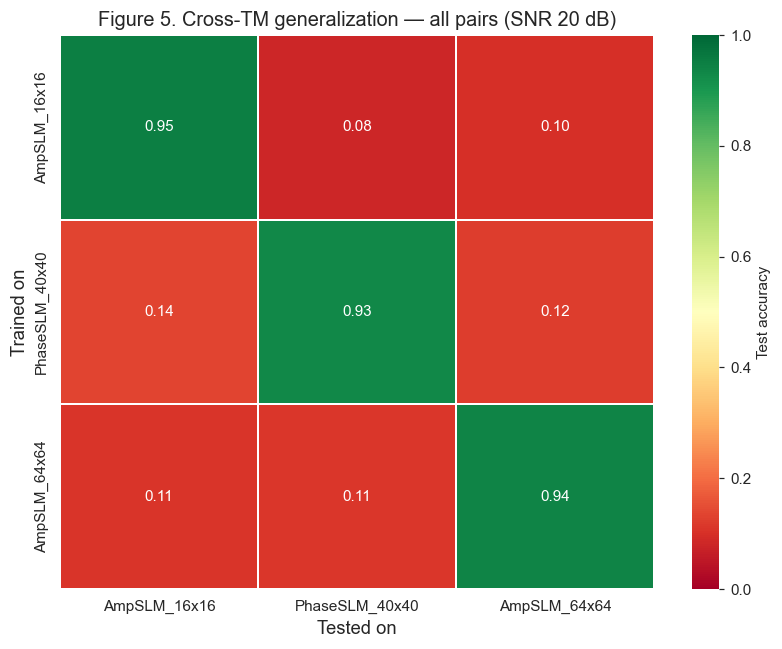


Diagonal (same-TM)     mean accuracy: 0.942  (range: 0.932–0.951)
Off-diagonal (cross-TM) mean accuracy: 0.110  (range: 0.082–0.136)


In [12]:
# Figure 5 — cross-TM accuracy heatmap
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(cross_tm_acc, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, cbar_kws={'label': 'Test accuracy'},
            xticklabels=TM_NAMES, yticklabels=TM_NAMES, ax=ax, linewidths=1, linecolor='white')
ax.set_xlabel('Tested on', fontsize=12)
ax.set_ylabel('Trained on', fontsize=12)
ax.set_title('Figure 5. Cross-TM generalization — all pairs (SNR 20 dB)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/fig5_cross_tm.png')
plt.show()

# Report diagonal vs off-diagonal means
diag = np.diag(cross_tm_acc)
offdiag_mask = ~np.eye(N_TMS, dtype=bool)
offdiag = cross_tm_acc[offdiag_mask]
print(f'\nDiagonal (same-TM)     mean accuracy: {diag.mean():.3f}  (range: {diag.min():.3f}–{diag.max():.3f})')
print(f'Off-diagonal (cross-TM) mean accuracy: {offdiag.mean():.3f}  (range: {offdiag.min():.3f}–{offdiag.max():.3f})')


### Reading the heatmap

- **Diagonal (green, high accuracy)**: each classifier works well on the TM it was trained on. Differences between the three diagonal entries reflect the TMs' different input resolutions — a 64×64 input carries more of the original digit's information than a 16×16 input, so in principle harder or easier classification depending on how reconstructable each is.
- **Off-diagonal (red/low accuracy)**: classifiers trained on one medium fail when applied to a different medium. Each TM is a completely different random projection of the input, so a network trained on TM_A has no reason to work on TM_B. This collapse to near-chance is the honest, expected result.

### The takeaway
**Each physical scattering medium needs its own calibrated classifier.** In deployment, this means if the medium changes (tissue type, swap of diffuser, temperature drift), the classifier must be retrained — a known limitation of speckle-based imaging and a natural direction for future work (e.g., meta-learning or explicit TM-aware architectures).


---
## 9. Summary of Results


In [13]:
import pandas as pd

summary_rows = []
for snr_name in SNR_NAMES:
    summary_rows.append(('Noise robustness (AmpSLM_16x16)',
                         f'CNN @ {snr_name}', snr_results[snr_name]['acc']))

for i, train_name in enumerate(TM_NAMES):
    for j, test_name in enumerate(TM_NAMES):
        label = f'Train={train_name}, Test={test_name}'
        summary_rows.append(('Cross-TM (SNR 20 dB)', label, float(cross_tm_acc[i, j])))

summary_df = pd.DataFrame(summary_rows, columns=['Experiment', 'Condition', 'Test accuracy'])
summary_df['Test accuracy'] = summary_df['Test accuracy'].round(3)
display(summary_df)


,Experiment,Condition,Test accuracy
0,Noise robustness (AmpSLM_16x16),CNN @ noiseless,0.944
1,Noise robustness (AmpSLM_16x16),CNN @ 40 dB,0.950
2,Noise robustness (AmpSLM_16x16),CNN @ 20 dB,0.951
3,Noise robustness (AmpSLM_16x16),CNN @ 10 dB,0.950
4,Cross-TM (SNR 20 dB),"Train=AmpSLM_16x16, Test=AmpSLM_16x16",0.951
5,Cross-TM (SNR 20 dB),"Train=AmpSLM_16x16, Test=PhaseSLM_40x40",0.082
6,Cross-TM (SNR 20 dB),"Train=AmpSLM_16x16, Test=AmpSLM_64x64",0.101
7,Cross-TM (SNR 20 dB),"Train=PhaseSLM_40x40, Test=AmpSLM_16x16",0.136
8,Cross-TM (SNR 20 dB),"Train=PhaseSLM_40x40, Test=PhaseSLM_40x40",0.932
9,Cross-TM (SNR 20 dB),"Train=PhaseSLM_40x40, Test=AmpSLM_64x64",0.123


### Key takeaways

1. **Speckle patterns from real scattering media are classifiable.** Despite looking like noise, speckle from three independently measured TMs preserves enough class information that a small CNN reaches high accuracy at realistic noise levels. Reconstruction is not a prerequisite for recognition.

2. **Classification is robust to substantial camera noise.** Accuracy degrades gracefully from noiseless down to SNR 10 dB. In the high-SNR regime (20–40 dB), the network is near saturation on this task.

3. **Classifiers are tied to their specific scattering medium.** The cross-TM heatmap shows a sharp diagonal-vs-off-diagonal split: training on medium A and testing on medium B collapses to near-chance. Each physical diffuser requires its own calibrated classifier a practical constraint for real deployment.

4. **Real TMs validate the approach.** Unlike a purely simulated forward model, every experiment in this notebook used transmission matrices reconstructed from actual experimental measurements. The results show that the physical-layer + CNN paradigm works on real scattering data, not just idealized Gaussian approximations.


